# Biodiversity-loss evidence differs across geographies

In [27]:
import importlib
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [29]:
from data_helpers import results_config, visualization
from data_helpers.analysis import driver_composition
from data_helpers.analysis.geo.geography import SHAPEFILE_PATH, load_polygons
from data_helpers.prep import evidence_corpus_prep

# Pick up local helper changes when rerunning in an existing notebook kernel.
importlib.reload(results_config)
importlib.reload(driver_composition)

In [ ]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
DRIVER_CONFIG = RESULTS_CONFIG["driver_composition"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]
THREAT_ORDER, THREAT_COLORS, THREAT_DISPLAY_NAMES = results_config.threat_l0_display(
    RESULTS_CONFIG
)

INCOME_GROUPS = INCOME_CONFIG["group_order"]
TIER_ORDER = INCOME_CONFIG["tier_order"]
LOWER_TIER = set(INCOME_CONFIG["tiers"]["Lower-income tier"])
PERIOD_BINS, PERIOD_LABELS = driver_composition.publication_period_bins(
    DRIVER_CONFIG["publication_periods"]
)

MAPPING_PATH = PROJECT_ROOT / INCOME_CONFIG["world_bank_mapping"]
HISTORICAL_PATH = (
    PROJECT_ROOT
    / INCOME_CONFIG["world_bank_snapshot_curated"]
    / DRIVER_CONFIG["historical_classifications_file"]
)

OUTPUT_DIR = PROJECT_ROOT / DRIVER_CONFIG["output_directory"]
DATA_DIR = OUTPUT_DIR / DRIVER_CONFIG["data_subdirectory"]
TABLE_DIR = OUTPUT_DIR / DRIVER_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / DRIVER_CONFIG["figure_subdirectory"]
for directory in (DATA_DIR, TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

# Provenance: the complete set of inputs this result depends on.
print("Inputs")
for label, path in (
    ("dataset          ", CORPUS_DIR),
    ("country mapping  ", MAPPING_PATH),
    ("income snapshot  ", HISTORICAL_PATH),
    ("country polygons  ", SHAPEFILE_PATH),
):
    status = "found" if path.exists() else "MISSING"
    print(f"  {label} {path.relative_to(PROJECT_ROOT)}  [{status}]")
missing = [
    path
    for path in (CORPUS_DIR, MAPPING_PATH, HISTORICAL_PATH, SHAPEFILE_PATH)
    if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Run the data-processing prep notebooks first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

## 1. Biodiveristy loss articles and income matching 

Start from the base dataset of 253k+ articles. Exclude recrods based on
- an unresolved country iso code in label; or
- iso code without a match World Bank economy.
- Final dataset size is 251k now

Expand the grain. One article can map multiple countries. Update shape has 270k rows. Here
- 170k looks like iso codes
- 100k have special labelsl ike unclear, not applicable

Adjustments for world bank join based on publicaiton year = income classificaiton year in WB classification.
- Exclude for 5k records. Majorly excluded from 2026 for figure purpuse. Minor dropped as the publication year and wb income year didn't match
- 165k looks like iso code now in combination of article - country

This yields
- 146k at unique articles / 213 unique countries 

In [ ]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(
    CORPUS_DIR
).load(columns=["UT", "publication_year", "s2_dir", "pred_study_design", "pred_countries", "pred_threat_l0"]).publications

evidence_preparation = driver_composition.prepare_historical_income_evidence(
    corpus_df,
    mapping_path=MAPPING_PATH,
    historical_path=HISTORICAL_PATH,
    income_groups=INCOME_GROUPS,
    direction=DRIVER_CONFIG["direction"],
    sensitivity_study_design=DRIVER_CONFIG["sensitivity_study_design"],
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
)
linked_country_df = evidence_preparation.primary
country_counts = driver_composition.build_country_article_counts(linked_country_df)
figure_publication_count = linked_country_df["UT"].nunique()
country_polygons = load_polygons(
    simplify_tolerance=0.2, preserve_topology=True
)

display(
    evidence_preparation.audit.style.format({"value": "{:,}"}).hide(axis="index")
)
print(f"Reclassified share: {evidence_preparation.reclassified_share:.1%}")
print(
    f"All panels use {figure_publication_count:,} country-resolved biodiversity-loss "
    f"publications ({DRIVER_CONFIG['primary_start_year']}–"
    f"{DRIVER_CONFIG['primary_end_year']}, all study designs)."
)

metric,value
Negative publications before country exclusions,"253,081"
Excluded publications (either reason below),"1,821"
Unresolved country token,892
Valid ISO3 without World Bank economy,933
Negative publications after country exclusions,"251,260"
Publication–country token rows,"270,679"
Resolvable to a World Bank country code,"170,425"
Special label (Unclear / Not Applicable / aggregate),"100,254"
World Bank-linked publication–country assignments,"170,424"
World Bank-linked unique publications,"151,268"


Reclassified share: 10.6%
All panels use 146,630 country-resolved biodiversity-loss publications (2000–2025, all study designs).


## 2. Geographic coverage, threat composition, and the extreme-group contrast

Panel **a** maps the shared 146,630-publication all-design subset. Panel **b** gives the
same publications' within-income-group composition and shows each group count beneath its
abbreviated label.
Panel **c** gives the HIC-minus-LIC difference in each category's share, in percentage
points, with 95% bootstrap intervals. The ten contrasted layers in panel b follow panel
c's signed order from bottom to top; `Other threats` and `Unclear` form the residual block
at the top.

This is Figure `income_composition` in the manuscript. Each panel's data is prepared and
summarized in its own subsection below (a, b, c); the combined figure is built and shown
once, at the end, from all three. Section **c** lists every threat's contrast; the largest
gaps are the ones quoted in the main text.

### a. World map data

In [ ]:
map_counts = country_counts["record_count"]
print(
    f"Panel a data: {len(country_counts):,} countries with linked publications, "
    f"covering {figure_publication_count:,} publications.\n"
    f"Articles per country — min {map_counts.min():,}, "
    f"median {int(map_counts.median()):,}, max {map_counts.max():,}."
)
display(
    country_counts.sort_values("record_count", ascending=False)
    .head(5)
    .style.format({"record_count": "{:,}"})
    .hide(axis="index")
)

Panel a data: 213 countries with linked publications, covering 146,630 publications.
Articles per country — min 1, median 148, max 25,667.


iso3,country,region,record_count
USA,United States,North America,"25,667"
CHN,China,East Asia & Pacific,"20,593"
BRA,Brazil,Latin America & Caribbean,"8,631"
CAN,Canada,North America,"6,794"
IND,India,South Asia,"6,668"


### b. World Bank income group classificaiton and biodiversity threats data

In [ ]:
composition_analysis = driver_composition.analyze_income_composition(
    linked_country_df,
    threat_order=THREAT_ORDER,
    income_groups=INCOME_GROUPS,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"],
)
observed_threat_order = composition_analysis.observed_threat_order

group_sizes = composition_analysis.group_counts["unique_publications"]
print(
    f"Panel b data: {len(INCOME_GROUPS)} income groups x "
    f"{len(observed_threat_order)} threat categories.\n"
    f"Group sizes — {group_sizes.idxmin()} {group_sizes.min():,} to "
    f"{group_sizes.idxmax()} {group_sizes.max():,} publications."
)
display(composition_analysis.group_counts.style.format("{:,}"))

Panel b data: 4 income groups x 12 threat categories.
Group sizes — Low income 6,956 to High income 73,234 publications.


,unique_publications,represented_countries
historical_income_group,,
Low income,"6,956",70
Lower middle income,"23,549",101
Upper middle income,"48,122",89
High income,"73,234",85


### c. High-minus-low contrast — data

Compares the two *extreme* income groups only (High income minus Low income), reusing
panel b's `composition_analysis` — no recomputation. For each threat, `high_minus_low_pp`
is the gap between that threat's share of High-income research and its share of
Low-income research, in percentage points: negative means Low-income research emphasizes
it more, positive means High-income research does. All threat categories are shown below.

**Bootstrap methodology** (`bootstrap_extreme_contrast` in `driver_composition.py`), walked
through on the **Pollution** row from the table below (Low income 14.94%, High income
24.43%, observed gap +9.49pp, 95% CI [8.67, 10.31]):

- **Share estimate.** A group's share of a threat is that group's *total* attribution
  weight for the threat divided by its *total* attribution weight overall — not a raw
  publication count — because a publication can be fractionally split across income
  groups (see panel b). Toy example with 3 Low-income publications: Paper A puts its full
  weight (1.0) on Pollution; Paper B splits evenly (0.5 Pollution, 0.5 Agriculture,
  because it also names a country in another income group); Paper C puts none of its
  weight on Pollution. Pollution's share = (1.0 + 0.5 + 0.0) / 3.0 = 50%. The real
  Low-income Pollution share (14.94%) is this same sum-of-weights ÷ total-weight
  calculation over all 6,956 Low-income publications.
- **Resampling.** The Low-income and High-income publications are resampled
  independently of each other, with replacement, at their original sample sizes (6,956
  and 73,234 respectively) — independently because they are treated as two separate
  populations (see **Limitations** below for the one place this isn't quite exact). "With
  replacement" means a single draw of 6,956 Low-income publications can (and typically
  does) include some papers 0 times and others 2 or 3 times, rather than being a plain
  reshuffle of the same 6,956 papers once each.
- **Replicates.** The high-minus-low share gap is recomputed on each resampled pair and
  the whole draw-and-recompute step is repeated `bootstrap_replicates` = 1,000 times,
  producing an empirical distribution of 1,000 simulated Pollution gaps — e.g. one draw
  might land at High 24.1% / Low 15.3% (gap +8.8pp), another at High 24.7% / Low 14.6%
  (gap +10.1pp), and so on, 1,000 times.
- **Interval.** `bootstrap_ci_low`/`bootstrap_ci_high` are the 2.5th and 97.5th
  percentiles of that 1,000-gap distribution — a standard nonparametric percentile
  bootstrap 95% interval, not a normal-approximation interval. For Pollution, those
  percentiles are 8.67 and 10.31, bracketing the observed +9.49pp.
- **`interval_excludes_zero`** flags threats whose entire interval sits on one side of
  zero, i.e., where all 1,000 resamples agree on the direction of the gap. Pollution's
  interval [8.67, 10.31] never crosses zero → flagged `True`. Contrast with Human
  Intrusions & Disturbance, gap −0.16pp with interval [−0.46, 0.13] — it *does* straddle
  zero, so some resamples say Low-income emphasizes it more and some say High-income
  does → flagged `False`.

**Limitations** (methodological caveats worth being aware of, not fixed here):

- **No multiple-comparison correction.** Each threat's `interval_excludes_zero` is an
  independent 95% test. Read across all 12 threats at once, not adjusting for that
  inflates the chance of at least one spurious flag — with 12 independent tests at 5%
  each, ~46% odds of ≥1 false positive even if nothing were really different between
  groups. Treat gaps whose interval barely excludes zero (e.g. Transportation & Service
  Corridors, +1.06pp, CI [0.84, 1.29]) more cautiously than the large, unambiguous ones
  (Agriculture, Pollution).
- **The two groups are not perfectly disjoint.** 164 publications (2.4% of the 6,956
  Low-income group, 0.2% of the 73,234 High-income group) study countries in *both*
  groups — e.g. a comparative study naming one Low-income and one High-income country —
  so "independently resampled" is a standard, accepted simplification for overlapping
  subpopulations rather than a literal independence guarantee.</cell id="c1066998">


In [ ]:
contrast_table = composition_analysis.extreme_contrast[
    [
        "threat",
        "low_income_share_pct",
        "high_income_share_pct",
        "high_minus_low_pp",
        "bootstrap_ci_low",
        "bootstrap_ci_high",
    ]
].round(2)
print(
    f"Panel c data: High income (n={group_sizes['High income']:,}) minus "
    f"Low income (n={group_sizes['Low income']:,}), "
    f"{DRIVER_CONFIG['bootstrap_replicates']:,} bootstrap replicates, "
    f"all {len(contrast_table)} threat categories, sorted by the size of the gap."
)
display(contrast_table)

Panel c data: High income (n=73,234) minus Low income (n=6,956), 1,000 bootstrap replicates, all 12 threat categories, sorted by the size of the gap.


,threat,low_income_share_pct,high_income_share_pct,high_minus_low_pp,bootstrap_ci_low,bootstrap_ci_high
0,Pollution,14.94,24.43,9.49,8.67,10.31
1,"Invasive & Other Problematic Species, Genes & ...",8.67,17.07,8.40,7.64,9.10
2,Climate Change & Severe Weather,10.44,17.23,6.79,6.10,7.48
3,Natural System Modifications,6.54,10.07,3.52,3.01,3.98
4,Transportation & Service Corridors,1.26,2.32,1.06,0.84,1.29
5,Energy Production & Mining,1.76,2.08,0.31,0.07,0.54
6,Unclear,3.07,2.94,-0.13,-0.58,0.26
7,Human Intrusions & Disturbance,1.78,1.62,-0.16,-0.46,0.13
8,Other Options,1.64,1.24,-0.40,-0.71,-0.10
9,Residential & Commercial Development,6.23,4.00,-2.23,-2.71,-1.73


### Combined figure

All three panels drawn together as one composite (this is Figure `income_composition` in
the manuscript).

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/02_income_composition/figures/income_composition.pdf


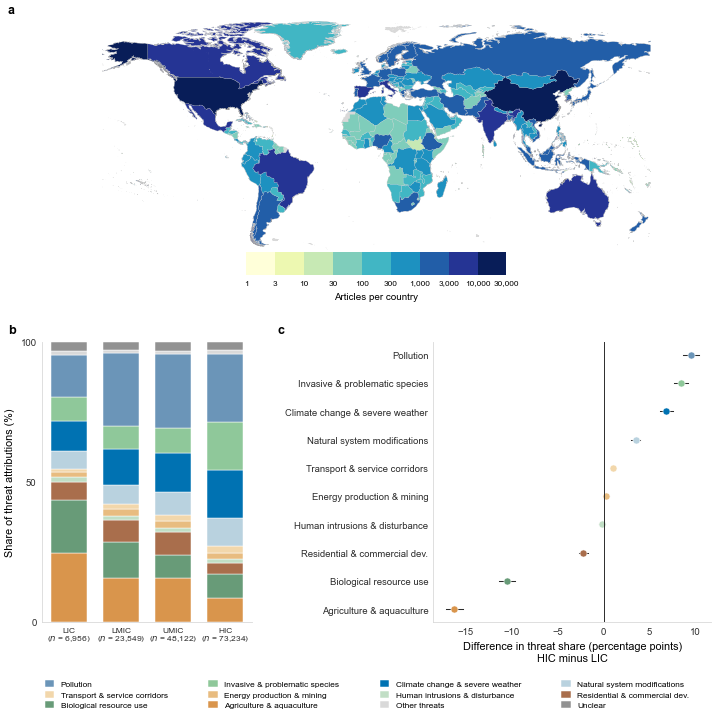

In [ ]:
composition_figure = driver_composition.plot_income_composition(
    composition_analysis,
    income_groups=INCOME_GROUPS,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_DISPLAY_NAMES,
    country_counts=country_counts,
    polygons=country_polygons,
    contrast_excluded_threats=DRIVER_CONFIG["contrast_plot_excluded_threats"],
)
visualization.save_figure(
    composition_figure,
    FIGURE_DIR / DRIVER_CONFIG["composition_figure_filename"],
    formats=["pdf"],
    dpi=300,
    pad_inches=0.05,
)
plt.show()

## 3. Hold region and publication period constant

Income groups differ in which world regions and publication periods they draw on, so a
raw contrast could reflect the geography and timing of research rather than income. Pool
low and lower-middle into a lower-income tier and upper-middle and high into a
higher-income tier, then directly standardize both tiers to the same World Bank region ×
five-year-period distribution, using only strata present in both tiers. This is
descriptive adjustment, not a causal model, and pooling attenuates the contrast relative
to the extreme-group comparison in section 2.

The table below is Supplementary Table `income_standardized`.

In [ ]:
standardization_analysis = driver_composition.analyze_standardized_tiers(
    linked_country_df,
    lower_tier_groups=LOWER_TIER,
    period_bins=PERIOD_BINS,
    period_labels=PERIOD_LABELS,
    threat_order=observed_threat_order,
    tier_order=TIER_ORDER,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"] + 1,
)
standardization_meta = standardization_analysis.metadata

print(
    f"Shared regions: {standardization_meta['common_regions']}; "
    "shared region × period strata: "
    f"{standardization_meta['common_region_period_strata']}"
)
display(
    standardization_analysis.contrasts.loc[
        standardization_analysis.contrasts["threat"].isin(
            DRIVER_CONFIG["focus_threats"]
        ),
        [
            "threat",
            "raw_higher_minus_lower_pp",
            "region_standardized_higher_minus_lower_pp",
            "region_period_standardized_higher_minus_lower_pp",
            "joint_bootstrap_ci_low",
            "joint_bootstrap_ci_high",
        ],
    ].round(2)
)

Shared regions: 6; shared region × period strata: 28


,threat,raw_higher_minus_lower_pp,region_standardized_higher_minus_lower_pp,region_period_standardized_higher_minus_lower_pp,joint_bootstrap_ci_low,joint_bootstrap_ci_high
0,"Invasive & Other Problematic Species, Genes & ...",5.71,4.73,4.83,4.07,5.59
1,Climate Change & Severe Weather,3.48,5.28,3.05,1.96,4.40
2,Pollution,1.55,-0.30,1.83,0.58,2.95
4,Natural System Modifications,2.53,0.14,0.66,-0.07,1.26
10,Biological Resource Use,-5.73,-4.69,-4.09,-4.92,-3.36
11,Agriculture & Aquaculture,-6.37,-6.78,-7.70,-8.58,-6.80


## 4. Robustness of the contrast

Recalculate the extreme-group contrast under five alternative specifications:
- observational studies only, current rather than historical
- income classification, a shifted fiscal-year boundary, the partial 2026 year included,
- and give full weight per income group. 

Rank correlation and direction agreement near one mean the reported pattern does not depend on these choices.

This is the Supplementary "Sensitivity analyses" paragraph in main text.

In [ ]:
sensitivity_df = driver_composition.build_sensitivity_summary(
    evidence_preparation,
    composition_analysis,
    income_groups=INCOME_GROUPS,
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
    partial_end_year=DRIVER_CONFIG["partial_end_year"],
)
display(sensitivity_df.round(3))

,comparison,rank_correlation,largest_change_pp,direction_agreement
0,Observational study design only,1.000,1.969,1.000
1,Current income classification,1.000,5.490,0.917
2,FY = publication year + 1,1.000,0.621,1.000
3,Include partial 2026,1.000,0.126,1.000
4,Full weight per income group (previous primary),0.993,0.818,1.000


## 5. Export

The four core analytical tables for this result: within-group composition,
extreme-group bootstrap contrast, region–period standardized tier contrast,
and the sensitivity summary.

In [ ]:
assert linked_country_df["UT"].nunique() == 146_630
assert figure_publication_count == 146_630
assert country_counts.shape[0] == 213
assert country_counts["record_count"].sum() == 165_174
assert evidence_preparation.country_exclusions["UT"].nunique() == 1_821
assert composition_analysis.group_counts["unique_publications"].tolist() == [
    6_956, 23_549, 48_122, 73_234
]
assert country_counts["record_count"].max() == 25_667
assert set(country_counts["iso3"]).issubset(
    set(country_polygons["ISO_3"].dropna())
)

In [ ]:
written_paths = driver_composition.export_manuscript_tables(
    evidence_preparation,
    composition_analysis,
    standardization_analysis,
    sensitivity_df,
    data_directory=DATA_DIR,
    table_directory=TABLE_DIR,
    classified_assignments_file=DRIVER_CONFIG["classified_assignments_file"],
)
figure_paths = sorted(FIGURE_DIR.glob("*.pdf"))
for path in [*written_paths, *figure_paths]:
    print(path.relative_to(PROJECT_ROOT))

manifest = {
    "result": "02_income_composition",
    "method_details": {
        "analysis_scope": {
            "direction": DRIVER_CONFIG["direction"],
            "years": (
                f"{DRIVER_CONFIG['primary_start_year']}-"
                f"{DRIVER_CONFIG['primary_end_year']} complete publication years"
            ),
            "n_publications": int(figure_publication_count),
            "n_countries": int(len(country_counts)),
            "income_groups": list(INCOME_GROUPS),
            "n_threat_classes": int(len(observed_threat_order)),
        },
        "composition": {
            "grain": "UT x country x distinct threat",
            "income_assignment": (
                "World Bank income group matched to the publication year"
            ),
            "fractional_weight_formula": (
                "w_i,c,t = 1 / (number of countries_i x number of threats_i); "
                "weights sum to one per publication across all country-threat pairs"
            ),
            "group_publication_counts": {
                str(group): int(count) for group, count in group_sizes.items()
            },
        },
        "contrasts": {
            "extreme_group_comparison": "High income minus Low income, percentage points",
            "bootstrap_replicates": int(DRIVER_CONFIG["bootstrap_replicates"]),
            "bootstrap_seed": int(DRIVER_CONFIG["random_seed"]),
            "standardized_comparison": (
                "Higher-income tier minus Lower-income tier, standardized over "
                "shared World Bank region x publication-period strata"
            ),
            "sensitivity_table": (
                "Recalculates the extreme-group contrast under the configured "
                "weighting, time-window, and study-design choices"
            ),
        },
    },
    "artifacts": {
        "data/historical_income_publication_country_assignments.parquet": (
            "Publication-country assignments with historical income groups; "
            "retained because Result 5 uses it to reproduce the same evidence base."
        ),
        "csv/income_group_threat_composition.csv": (
            "Fractional threat composition within each historical income group."
        ),
        "csv/high_minus_low_income_bootstrap.csv": (
            "High-income minus low-income threat-share contrasts with bootstrap intervals."
        ),
        "csv/region_period_standardized_tier_contrast.csv": (
            "Tier contrasts standardized over shared region-period strata."
        ),
        "csv/sensitivity_summary.csv": (
            "Summary of contrast estimates under alternative analytical choices."
        ),
        "figures/income_composition.pdf": (
            "Country coverage, income-group threat composition, and extreme-group contrast."
        ),
    },
}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2) + "\n", encoding="utf-8"
)
print(manifest_path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/02_income_composition/csv/income_group_threat_composition.csv
notebooks/results/outputs/02_income_composition/csv/high_minus_low_income_bootstrap.csv
notebooks/results/outputs/02_income_composition/csv/region_period_standardized_tier_contrast.csv
notebooks/results/outputs/02_income_composition/csv/sensitivity_summary.csv
notebooks/results/outputs/02_income_composition/figures/income_composition.pdf
notebooks/results/outputs/02_income_composition/manifest.json
